|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Autoencoders<h1>|
|<h2>Lecture:</h2>|<h1><b>Denoising MNIST<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [78]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)
# dataNorm = data

# convert to tensor
dataT = torch.tensor( dataNorm ).float()

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


# Create the DL model

In [79]:
# create a class for the model
def createTheMNISTAE():

  class aenet(nn.Module):
    def __init__(self):
      super().__init__()
      nInput = 784
      nEnc = 250
      nLat = 75
      nDec = nEnc

      ### input layer
      self.input = nn.Linear(nInput,nEnc)

      ### encoder layer
      self.enc = nn.Linear(self.input.out_features,nLat)

      ### latent layer
      self.lat = nn.Linear(self.enc.out_features,nDec)

      ### decoder layer
      self.dec = nn.Linear(self.lat.out_features,nInput)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.enc(x) )
      x = F.relu( self.lat(x) )
      return torch.sigmoid( self.dec(x) )

  # create the model instance
  net = aenet()

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [80]:
# test the model with a bit of data
net,lossfun,optimizer = createTheMNISTAE()

X = dataT[:5,:]
yHat = net(X)

print(X.shape)
print(yHat.shape)

torch.Size([5, 784])
torch.Size([5, 784])


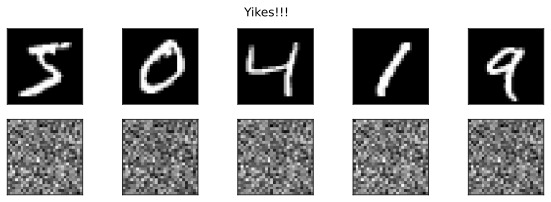

In [81]:
# let's see what the model did!
fig,axs = plt.subplots(2,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(yHat[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.suptitle('Yikes!!!')
plt.show()

# Create a function that trains the model

In [82]:
def function2trainTheModel():

  # create a new model
  net,lossfun,optimizer = createTheMNISTAE()
  
  # Generate random inedexes list over the dataset
  randomidx_len = 8
  randomidx_list = np.random.choice(dataT.shape[0],size=dataT.shape[0])

  # number of epochs
  numepochs = randomidx_list.shape[0] // randomidx_len
  
  # initialize losses
  losses = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # select a random set of images
    randomidx = randomidx_list[epochi*randomidx_len:(epochi+1)*randomidx_len]
    X = dataT[randomidx,:]

    # forward pass and loss
    yHat = net(X)
    loss = lossfun(yHat,X)

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # losses in this epoch
    losses[epochi] = loss.item()
  # end epochs

  # function output
  return losses,net

# Run the model and show the results!

Final loss: 0.0076


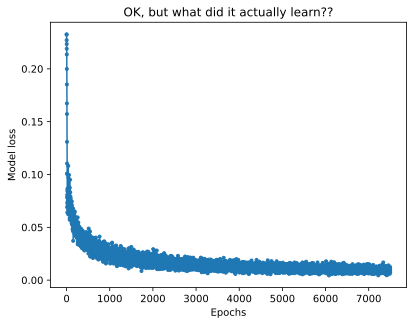

In [83]:
# train the model (90s)
losses,net = function2trainTheModel()
print(f'Final loss: {losses[-1]:.4f}')

# visualize the losses
plt.plot(losses,'.-')
plt.xlabel('Epochs')
plt.ylabel('Model loss')
plt.title('OK, but what did it actually learn??')
plt.show()

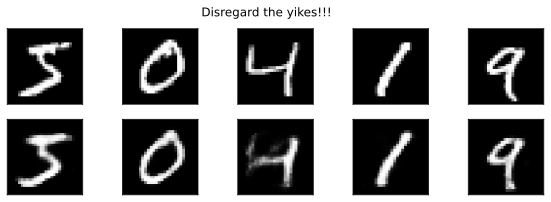

In [84]:
# Repeat the visualization when testing the model
X = dataT[:5,:]
yHat = net(X)


# let's see what the model did!
fig,axs = plt.subplots(2,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(yHat[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.suptitle('Disregard the yikes!!!')
plt.show()

# Add noise to see a use case of an autoencoder

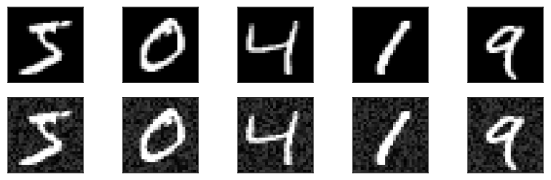

In [100]:
# grab a small set of images
X = dataT[:10,:]

# add noise
max_val = torch.max(X).detach().long().float().item()
Xnoise = X + max_val * torch.rand_like(X)/4

# clip at max
Xnoise[Xnoise>max_val] = max_val

# show the noisy images
fig,axs = plt.subplots(2,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(Xnoise[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.show()

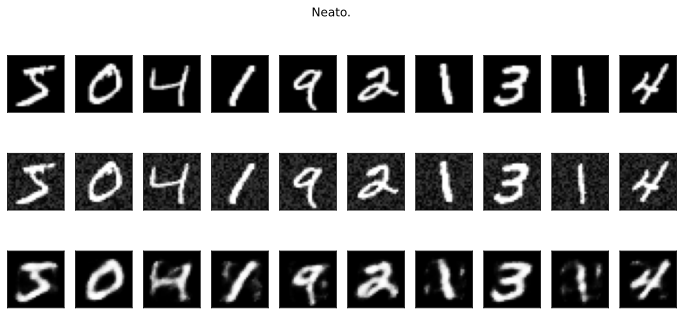

In [101]:
# run through the model
Y = net(Xnoise)


# show the noisy images
fig,axs = plt.subplots(3,10,figsize=(12,5))

for i in range(10):
  axs[0,i].imshow(X[i,:].view(28,28).detach() ,cmap='gray')
  axs[1,i].imshow(Xnoise[i,:].view(28,28).detach() ,cmap='gray')
  axs[2,i].imshow(Y[i,:].view(28,28).detach() ,cmap='gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])
  axs[2,i].set_xticks([]), axs[2,i].set_yticks([])

plt.suptitle('Neato.')
plt.show()

# Additional explorations

In [ ]:
# 1) Because these are continuous data, mean-squared-error is the correct loss function. But I mentioned in the previous
#    video that binary cross-entropy loss is *sometimes* used in autoencoders. Does the loss function make a difference
#    for this problem? Why?
# ANswer: The only appropriate loss function for this problem is MSE or any other regression loss because the output values
#         are continuous (pixel intensity values).
#
# 2) Change the number of units in the latent layer to 10. How does that affect the loss and denoising? Don't turn this
#    into a full parametric experiment -- that's for the next video!
# Answer: The loss in average stays seimiliar, but with more noise around it's mean. The denoising operation becomes mote wrong restored samples.
#
# 3) The code here picks samples randomly, which means many samples are skipped, and some could be repeated. Change the
#    code so that the model goes through every item exactly once per epoch. The order should be randomized to avoid
#    possible order effects. You'll probably want to reduce the number of epochs!
#
# 4) Is it necessary to normalize the data to a range of [0 1]? What are arguments for normalization, and arguments why
#    it may not be critical (in this problem)?
# Answer: The normalization is not necessary, but delivers better results. The arguments for normalisation are as usual possible gradients
# exploding/vanishing. The arguments against normalisation is that the model can learn the data distribution as is.
#
# 5) The autoencoder did a pretty decent job at denoising the images. How far can you push this? Try adding more noise
#    to the images and re-running the test code (you don't need to retrain the model). Is the autoencoder robust to a
#    a larger amount of noise?
# Answer: Already choosen 1/4 of a signal as a noice for this demo seems to be a good compromise between adding noise and still being able to denoise it.
# Going higher with the noise degrades the denoising quality quickly. The autoencoder is not robust to a larger amount of noise.